In [105]:
import pandas as pd
import numpy as np
import re
import pycountry
import matplotlib.pyplot as plt
import seaborn as sns

# import the data file
df_Data = pd.read_excel(
    r"D:\Projects\Data\Countries_Socioeconom_Profiles_Data\World_Development_Indicators.xlsx",
    sheet_name=0
)

# replace .. with nans
df_Data = df_Data.replace("..", np.nan)

# drop years with high persentage of nans
df_Data = df_Data.drop(columns=['2022 [YR2022]', '2023 [YR2023]', '2024 [YR2024]', '2025 [YR2025]'])

# Year columns
year_cols = [f"{year} [YR{year}]" for year in range(2010, 2022)]

df_Data = df_Data.melt(
    id_vars=["Country Name", "Country Code", "Series Name", "Series Code"],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

# Extract only the year
df_Data["Year"] = df_Data["Year"].str.extract(r"(\d{4})").astype(int)

# Make values numeric
df_Data["Value"] = pd.to_numeric(df_Data["Value"], errors="coerce")

# pivot df_Data
df_wide = df_Data.pivot(
    index=["Country Name", "Country Code", "Year"],
    columns="Series Name",
    values="Value"
).reset_index()

# normalize the names
df_wide.columns = (
    df_wide.columns
    .str.lower()
    .str.strip()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.replace(r"\s+", "_", regex=True)
)

rename_dict = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    
    "Access to electricity (% of population)": "access_to_electricity",
    "Agriculture, forestry, and fishing, value added (% of GDP)": "agriculture_value_added",
    "Broad money (% of GDP)": "broad_money",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)": "co2_emissions_per_capita",
    "Carbon intensity of GDP (kg CO2e per constant 2015 US$ of GDP)": "carbon_intensity_gdp",
    "Central government debt, total (% of GDP)": "government_debt",
    "Current health expenditure (% of GDP)": "health_expenditure",
    "Domestic credit to private sector (% of GDP)": "domestic_credit_private_sector",
    "Energy use (kg of oil equivalent per capita)": "energy_use_per_capita",
    "Exports of goods and services (% of GDP)": "exports",
    "Fertility rate, total (births per woman)": "fertility_rate",
    "Foreign direct investment, net inflows (% of GDP)": "fdi_inflows",
    "Forest area (% of land area)": "forest_area",
    "Fossil fuel energy consumption (% of total)": "fossil_fuel_consumption",
    "GDP growth (annual %)": "gdp_growth",
    "GDP per capita (constant 2015 US$)": "gdp_per_capita",
    "Gross capital formation (% of GDP)": "gross_capital_formation",
    "Imports of goods and services (% of GDP)": "imports",
    "Individuals using the Internet (% of population)": "internet_usage",
    "Industry (including construction), value added (% of GDP)": "industry_value_added",
    "Inflation, consumer prices (annual %)": "inflation",
    "Life expectancy at birth, total (years)": "life_expectancy",
    "Literacy rate, adult total (% of people ages 15 and above)": "literacy_rate",
    "Military expenditure (% of general government expenditure)": "military_expenditure",
    "Multidimensional poverty headcount ratio (World Bank) (% of population)": "multidimensional_poverty",
    "Population growth (annual %)": "population_growth",
    "Renewable electricity output (% of total electricity output)": "renewable_electricity",
    "Renewable energy consumption (% of total final energy consumption)": "renewable_energy",
    "Research and development expenditure (% of GDP)": "rd_expenditure",
    "School enrollment, primary (% gross)": "primary_school_enrollment",
    "Services, value added (% of GDP)": "services_value_added",
    "Trade (% of GDP)": "trade",
    "Unemployment, total (% of total labor force) (modeled ILO estimate)": "unemployment",
    "Urban population (% of total population)": "urban_population"
}

df_wide = df_wide.rename(columns=rename_dict)

# Retain only actual countries with valid ISO 3166-1 alpha-3 codes
valid_iso_codes = {country.alpha_3 for country in pycountry.countries}
df_countries = df_wide[df_wide['country_code'].isin(valid_iso_codes)].copy()

# calculate each country's overall percentage of missing data across all indicators and orders them from highest missingness to lowest.
feature_cols = df_countries.columns.difference(
    ["country_name", "country_code", "year"]
)

df_country_nan = (
    df_countries.groupby(["country_name", "country_code"])[feature_cols]
    .apply(lambda x: x.isna().sum().sum())
    .rename("nan_count")
    .reset_index()
)

# Total possible values per country
df_country_nan["total_values"] = (
    df_countries.groupby(["country_name", "country_code"])
    .size()
    .values * len(feature_cols)
)

# Percentage of missing values
df_country_nan["nan_percentage"] = (
    df_country_nan["nan_count"] /
    df_country_nan["total_values"]
)

df_country_nan = df_country_nan.sort_values(
    "nan_percentage",
    ascending=False
)

# delete country's with high persentage of nans
nan_per_delete = df_country_nan['nan_percentage'].quantile(q=0.85)
country_to_delete = df_country_nan[df_country_nan['nan_percentage'] >= nan_per_delete]
country_to_delete_list = country_to_delete['country_name'].tolist()



# delete columns with high nans
nan_summary = (
    pd.DataFrame({
        "nan_count": df_countries.isna().sum(),
        "nan_percentage": df_countries.isna().mean()
    })
    .reset_index(names="Series Name")
    .sort_values("nan_percentage", ascending=False)
)

for country in country_to_delete_list:

    df_countries = df_countries[df_countries['country_name'] != country]

null_per_max = 0.5

Series_Name_delete = nan_summary[nan_summary['nan_percentage'] >= null_per_max]
Series_Name_delete_list = Series_Name_delete['Series Name'].tolist()
df_countries = df_countries.drop(columns=Series_Name_delete_list)

In [106]:
df_countries.loc[
    df_countries["fossil_fuel_energy_consumption_of_total"] < 0,
    "fossil_fuel_energy_consumption_of_total"
] = np.nan

df_countries.loc[
    df_countries["gross_capital_formation_of_gdp"] < 0,
    "gross_capital_formation_of_gdp"
] = np.nan

df_countries.drop(columns=['exports_of_goods_and_services_of_gdp', 'imports_of_goods_and_services_of_gdp'], inplace=True)

############################################################

df_countries['trade_of_gdp_log'] = np.log1p(df_countries['trade_of_gdp'])
df_countries.drop(columns=['trade_of_gdp'], inplace=True)


index_components = [
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population"
]

internet_col = "individuals_using_the_internet_of_population"

# 1. Country-level mean
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(
        df_countries.groupby("country_code")[internet_col]
        .transform("mean")
    )
)

# 2. Year-level mean for countries with no Internet observations
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(
        df_countries.groupby("year")[internet_col]
        .transform("mean")
    )
)

# 3. Global mean as absolute last fallback
df_countries[internet_col] = (
    df_countries[internet_col]
    .fillna(df_countries[internet_col].mean())
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_countries[
    [f"{col}_z" for col in index_components]
] = scaler.fit_transform(
    df_countries[index_components]
)

df_countries["Socioeconomic_developmen_Index"] = (
    df_countries[[f"{col}_z" for col in index_components]]
    .mean(axis=1)
)

df_countries.drop(columns=[
    "access_to_electricity_of_population",
    "individuals_using_the_internet_of_population",
    "life_expectancy_at_birth_total_years",
    "urban_population_of_total_population",
    'individuals_using_the_internet_of_population_z',
    'life_expectancy_at_birth_total_years_z',
    'urban_population_of_total_population_z',
    'access_to_electricity_of_population_z'
], inplace=True)

############################################################

energy_cols = [
    "energy_use_kg_of_oil_equivalent_per_capita",
    "carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita"
]


# 1. Country-level mean
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(
        df_countries.groupby("country_code")[energy_cols]
        .transform("mean")
    )
)

# 2. Year-level mean for countries with no Internet observations
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(
        df_countries.groupby("year")[energy_cols]
        .transform("mean")
    )
)

# 3. Global mean as absolute last fallback
df_countries[energy_cols] = (
    df_countries[energy_cols]
    .fillna(df_countries[energy_cols].mean())
)


# 4. LOG TRANSFORMATION

df_log = np.log1p(df_countries[energy_cols])


# 5. STANDARDIZATION
scaler = StandardScaler()
z_cols = [f"{col}_z" for col in energy_cols]
df_countries[z_cols] = scaler.fit_transform(df_log)


# 6. CREATE ENERGY & ENVIRONMENTAL INDEX
df_countries["Energy_Environmental_Index"] = (
    df_countries[z_cols].mean(axis=1)
)


# 7. DROP ORIGINAL COMPONENTS
df_countries.drop(columns=energy_cols, inplace=True)
df_countries.drop(columns=['energy_use_kg_of_oil_equivalent_per_capita_z', 'carbon_dioxide_co2_emissions_excluding_lulucf_per_capita_t_co2ecapita_z'], inplace=True)

############################################################

df_countries['domestic_credit_to_private_sector_of_gdp_log'] = np.log1p(df_countries['domestic_credit_to_private_sector_of_gdp'])
df_countries.drop(columns= 'domestic_credit_to_private_sector_of_gdp', inplace=True)

############################################################

fdi = df_countries['foreign_direct_investment_net_inflows_of_gdp']

df_countries['fdi_log'] = np.sign(fdi) * np.log1p(np.abs(fdi))
df_countries.drop(columns='foreign_direct_investment_net_inflows_of_gdp', inplace=True)

############################################################

inflation = df_countries['inflation_consumer_prices_annual_']

df_countries['inflation_log'] = (np.sign(inflation)* np.log1p(np.abs(inflation)))
df_countries.drop(columns='inflation_consumer_prices_annual_', inplace=True)

############################################################

df_countries['broad_money_of_gdp_log'] = np.log1p(df_countries['broad_money_of_gdp'])
df_countries.drop(columns='broad_money_of_gdp', inplace=True)

############################################################

df_countries['gdp_per_capita_constant_2015_us_log'] = np.log1p(df_countries['gdp_per_capita_constant_2015_us'])
df_countries.drop(columns='gdp_per_capita_constant_2015_us', inplace=True)

############################################################

df_countries['military_expenditure_of_general_government_expenditure_log'] = np.log1p(df_countries['military_expenditure_of_general_government_expenditure'])
df_countries.drop(columns='military_expenditure_of_general_government_expenditure', inplace=True)

In [107]:
df_countries.drop(columns=['fossil_fuel_energy_consumption_of_total', 'military_expenditure_of_general_government_expenditure_log', 'broad_money_of_gdp_log', 'gross_capital_formation_of_gdp', 'trade_of_gdp_log', 'domestic_credit_to_private_sector_of_gdp_log'], inplace=True)

In [108]:
cols_with_nulls = df_countries.columns[df_countries.isna().any()].tolist()

for col in cols_with_nulls:

    df_countries[col] = (
        df_countries
        .groupby("country_code")[col]
        .transform(
            lambda x: x.interpolate(
                method="linear",
                limit=3,
                limit_area="inside"
            )
        )
    )

    df_countries[col] = (
    df_countries[col]
    .fillna(
        df_countries
        .groupby("country_code")[col]
        .transform(func="median")
        )
    )

    df_countries[col] = (
    df_countries[col]
    .fillna(
        df_countries
        .groupby("year")[col]
        .transform(func="median")
        )
    )


## **Now ready to start the model**

In [109]:
df_countries.head()

Series Name,country_name,country_code,year,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,gdp_growth_annual_,industry_including_construction_value_added_of_gdp,...,renewable_electricity_output_of_total_electricity_output,renewable_energy_consumption_of_total_final_energy_consumption,school_enrollment_primary_gross,services_value_added_of_gdp,unemployment_total_of_total_labor_force_modeled_ilo_estimate,Socioeconomic_developmen_Index,Energy_Environmental_Index,fdi_log,inflation_log,gdp_per_capita_constant_2015_us_log
0,Afghanistan,AFG,2010,26.210069,0.512445,8.569672,6.195,1.852782,14.362441,21.151421,...,81.752865,15.2,103.485603,48.879377,7.809,-1.471732,-0.381450,0.789874,1.156421,6.298712
1,Afghanistan,AFG,2011,23.743664,0.747279,8.561908,6.094,1.852782,0.426355,22.740252,...,74.400759,12.6,101.542084,49.696820,7.830,-1.435529,-0.334449,0.256985,2.549772,6.266113
2,Afghanistan,AFG,2012,24.390874,0.568510,7.897169,5.985,1.852782,12.752287,21.157807,...,79.797959,15.4,106.575317,50.579398,7.875,-1.173610,-0.361657,0.251102,2.007034,6.345512
3,Afghanistan,AFG,2013,22.810663,0.459073,8.805964,5.879,1.852782,5.600745,20.444605,...,81.008636,16.9,107.942841,52.682743,7.921,-1.160723,-0.390841,0.214951,2.126536,6.365790
4,Afghanistan,AFG,2014,22.137041,0.421983,9.528878,5.770,1.852782,2.724543,21.229663,...,85.461475,19.1,109.829453,52.990865,7.915,-0.948077,-0.413102,0.190343,1.735894,6.356362


In [110]:
features = df_countries.iloc[:, 3:].columns.to_list()

df_countries = (
    df_countries
    .groupby(["country_name", "country_code"])[features]
    .mean()
    .reset_index()
)

X = df_countries[features]

In [111]:
X.head()

Series Name,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,gdp_growth_annual_,industry_including_construction_value_added_of_gdp,population_growth_annual_,renewable_electricity_output_of_total_electricity_output,renewable_energy_consumption_of_total_final_energy_consumption,school_enrollment_primary_gross,services_value_added_of_gdp,unemployment_total_of_total_labor_force_modeled_ilo_estimate,Socioeconomic_developmen_Index,Energy_Environmental_Index,fdi_log,inflation_log,gdp_per_capita_constant_2015_us_log
0,25.289768,0.546955,11.999179,5.608250,1.852782,2.019658,17.003174,3.132810,83.374700,17.666667,106.649750,53.341627,9.648083,-1.010400,-0.392699,0.318243,1.493408,6.297712
1,18.125127,0.416100,6.554998,1.560750,28.733136,2.598157,24.423569,-1.349735,99.302258,39.283333,102.622453,43.673601,13.997833,0.429696,-0.509131,2.206033,1.101297,8.378579
2,10.049580,0.843120,5.588005,2.995750,0.815125,2.216667,37.119292,1.933966,0.780832,0.150000,109.603643,48.732253,11.372917,0.313264,0.059668,0.504859,1.677295,8.431120
3,12.619827,0.276847,2.385882,5.738833,55.430463,1.795835,43.247576,3.601488,69.305804,51.025000,115.986487,42.863933,16.499583,-0.879622,-1.006911,-0.941565,2.817234,8.125476
4,1.594202,0.194891,4.882605,1.562250,19.127519,0.217853,17.258362,0.772506,1.898920,0.400000,112.954781,71.577037,6.000417,0.102036,0.281182,2.181011,0.891913,9.703310


In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

c:\Users\minam\anaconda3\envs\data_science\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\minam\anaconda3\envs\data_science\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\minam\anaconda3\envs\data_science\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\minam\anaconda3\envs\data_science\Lib\site-packages\sklearn\cluster\_kmea

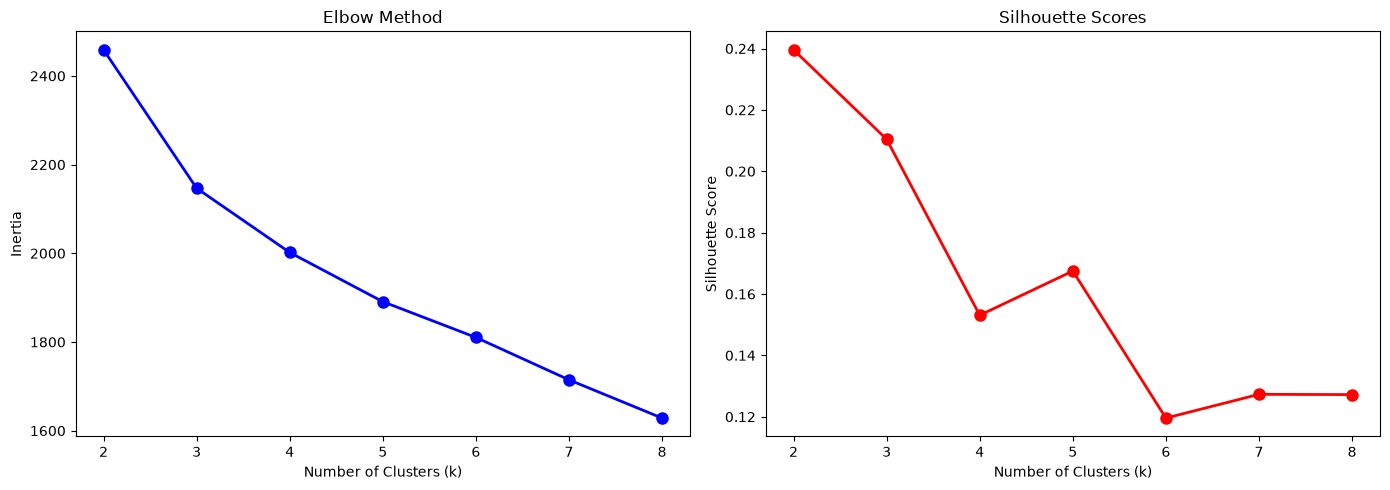

k = 2 | Silhouette Score = 0.2396
k = 3 | Silhouette Score = 0.2104
k = 4 | Silhouette Score = 0.1531
k = 5 | Silhouette Score = 0.1675
k = 6 | Silhouette Score = 0.1196
k = 7 | Silhouette Score = 0.1273
k = 8 | Silhouette Score = 0.1272


In [113]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []
K_range = range(2, 9)

# 1. Loop through possible cluster counts
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)

    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# 2. Plot Elbow Method & Silhouette Scores side-by-side
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Curve
ax[0].plot(K_range, inertia, "bo-", linewidth=2, markersize=8)
ax[0].set_xlabel("Number of Clusters (k)")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")

# Silhouette Curve
ax[1].plot(K_range, silhouette_scores, "ro-", linewidth=2, markersize=8)
ax[1].set_xlabel("Number of Clusters (k)")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Scores")

plt.tight_layout()
plt.show()

# Print Silhouette Scores directly
for k, score in zip(K_range, silhouette_scores):
    print(f"k = {k} | Silhouette Score = {score:.4f}")

In [114]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original number of features: {X_scaled.shape[1]}")
print(f"Reduced number of features: {X_pca.shape[1]}")

# View the variance explained by each individual component
print(f"Variance explained per component: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

Original number of features: 18
Reduced number of features: 2
Variance explained per component: [0.33076532 0.13380479]
Total variance explained: 46.46%


In [115]:
Kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_countries["Cluster"] = Kmeans.fit_predict(X_pca)

c:\Users\minam\anaconda3\envs\data_science\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [116]:
import joblib

# Save scaler
joblib.dump(scaler, "scaler.pkl")

# Save PCA
joblib.dump(pca, "pca.pkl")

# Save trained KMeans
joblib.dump(Kmeans, "kmeans.pkl")

# Save features
joblib.dump(features, "features.pkl")

['features.pkl']

In [117]:
cluster_summary = df_countries.groupby('Cluster')[features].mean().reset_index()
cluster_summary

Series Name,Cluster,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,gdp_growth_annual_,industry_including_construction_value_added_of_gdp,population_growth_annual_,renewable_electricity_output_of_total_electricity_output,renewable_energy_consumption_of_total_final_energy_consumption,school_enrollment_primary_gross,services_value_added_of_gdp,unemployment_total_of_total_labor_force_modeled_ilo_estimate,Socioeconomic_developmen_Index,Energy_Environmental_Index,fdi_log,inflation_log,gdp_per_capita_constant_2015_us_log
0,0,10.918000,0.451611,6.328541,2.669622,36.579152,3.480198,26.032117,1.145422,40.225452,30.495035,105.600097,54.901075,9.210794,-0.098198,-0.351189,1.252447,1.451068,8.220241
1,1,23.832638,0.335656,4.947471,4.640053,32.887203,4.127141,24.271210,2.499368,50.858055,69.470455,104.086496,45.722122,5.289064,-1.189123,-1.020163,1.170778,1.679338,6.913467
2,2,7.010164,1.104045,4.650073,2.433566,19.371296,1.946121,40.999378,1.645178,7.893716,3.802874,97.541942,46.154266,7.413330,0.350513,0.817849,0.934069,1.636502,8.964538
3,3,2.826061,0.307775,8.143418,1.636505,34.204992,2.067225,20.542476,0.477835,32.508342,19.425806,101.098902,66.451933,8.825703,0.754384,0.607669,1.492193,0.905685,9.978257


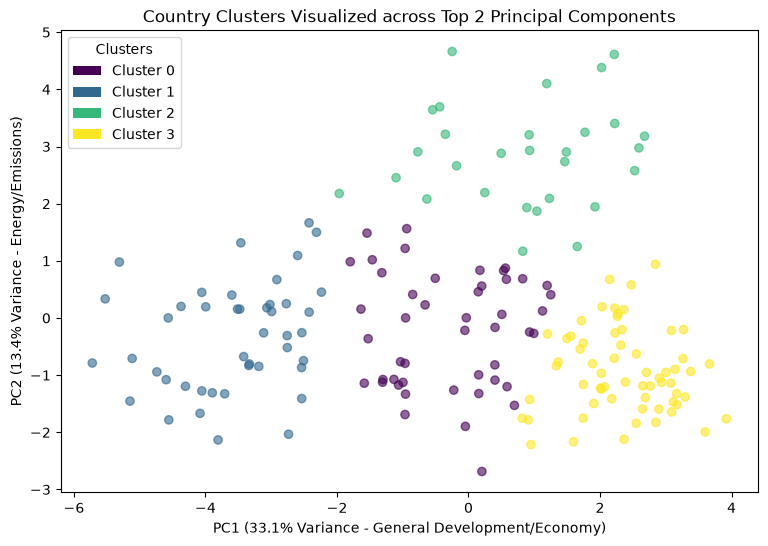

In [118]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Create the plot
plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=df_countries["Cluster"],
    cmap="viridis",
    alpha=0.6,
)

# Exact colors used by viridis for your 4 clusters
cluster_colors = {
    0: "#440154",
    1: "#31688e",
    2: "#35b779",
    3: "#fde725"
}

# Create legend entries
legend_elements = [
    Patch(facecolor=color, label=f"Cluster {cluster}")
    for cluster, color in cluster_colors.items()
]

plt.legend(
    handles=legend_elements,
    title="Clusters",
    loc="best"
)

plt.xlabel("PC1 (33.1% Variance - General Development/Economy)")
plt.ylabel("PC2 (13.4% Variance - Energy/Emissions)")
plt.title("Country Clusters Visualized across Top 2 Principal Components")

plt.show()

In [119]:
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

# Calculate quantitative metrics
sil = silhouette_score(X_pca, df_countries["Cluster"])
db = davies_bouldin_score(X_pca, df_countries["Cluster"])
ch = calinski_harabasz_score(X_pca, df_countries["Cluster"])

print(f"Silhouette Score: {sil:.3f}")
print(f"Davies-Bouldin Index: {db:.3f}")
print(f"Calinski-Harabasz Index: {ch:.3f}")

Silhouette Score: 0.452
Davies-Bouldin Index: 0.785
Calinski-Harabasz Index: 251.425


In [120]:
# from sklearn.cluster import KMeans
# from sklearn.metrics import (
#     silhouette_score,
#     davies_bouldin_score,
#     calinski_harabasz_score
# )
# from sklearn.decomposition import PCA

# for n_components in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:

#     pca = PCA(n_components=n_components, random_state=42)
#     X_pca = pca.fit_transform(X_scaled)

#     kmeans = KMeans(
#         n_clusters=4,
#         random_state=42,
#         n_init=10
#     )

#     labels = kmeans.fit_predict(X_pca)

#     print(
#         f"PCA={n_components} | "
#         f"Features={X_pca.shape[1]} | "
#         f"Variance={pca.explained_variance_ratio_.sum():.2%} | "
#         f"Silhouette={silhouette_score(X_pca, labels):.3f} | "
#         f"DB={davies_bouldin_score(X_pca, labels):.3f} | "
#         f"CH={calinski_harabasz_score(X_pca, labels):.1f}"
#     )

## **Cluster Analysis**

In [121]:
df_C0 = df_countries[df_countries['Cluster'] == 0]
df_C1 = df_countries[df_countries['Cluster'] == 1]
df_C2 = df_countries[df_countries['Cluster'] == 2]
df_C3 = df_countries[df_countries['Cluster'] == 3]

df_countries['fdi_original'] = np.sign(df_countries['fdi_log']) * np.expm1(np.abs(df_countries['fdi_log']))
df_countries['gdp_per_capita_original'] = np.sign(df_countries['gdp_per_capita_constant_2015_us_log']) * np.expm1(np.abs(df_countries['gdp_per_capita_constant_2015_us_log']))
df_countries['inflation_original'] = np.sign(df_countries['inflation_log']) * np.expm1(np.abs(df_countries['inflation_log']))

df_countries.sort_values(ignore_index=True, by='Cluster', inplace=True)

In [122]:
df_countries.head()

Series Name,country_name,country_code,agriculture_forestry_and_fishing_value_added_of_gdp,carbon_intensity_of_gdp_kg_co2e_per_constant_2015_us_of_gdp,current_health_expenditure_of_gdp,fertility_rate_total_births_per_woman,forest_area_of_land_area,gdp_growth_annual_,industry_including_construction_value_added_of_gdp,population_growth_annual_,...,unemployment_total_of_total_labor_force_modeled_ilo_estimate,Socioeconomic_developmen_Index,Energy_Environmental_Index,fdi_log,inflation_log,gdp_per_capita_constant_2015_us_log,Cluster,fdi_original,gdp_per_capita_original,inflation_original
0,Albania,ALB,18.125127,0.416100,6.554998,1.560750,28.733136,2.598157,24.423569,-1.349735,...,13.997833,0.429696,-0.509131,2.206033,1.101297,8.378579,0,8.079630,4351.818293,2.008065
1,Argentina,ARG,6.069658,0.324793,10.096737,2.143583,10.668332,1.199004,23.579906,0.862942,...,8.312583,0.832297,0.275620,0.982427,3.822565,9.488808,0,1.670929,13210.041609,44.721337
2,Armenia,ARM,15.214445,0.539678,10.385693,1.608333,11.589107,3.608333,25.944173,-0.286732,...,17.874000,0.380941,-0.362208,1.294420,1.278616,8.177051,0,2.648879,3557.345070,2.591664
3,Bangladesh,BGD,14.177220,0.426891,2.291866,2.233917,14.478263,6.373057,29.011809,0.879068,...,4.423917,-0.664314,-1.505142,0.649727,2.018380,7.145822,0,0.915017,1267.794454,6.526121
4,Bolivia,BOL,9.315389,0.601561,6.387413,2.880667,47.872559,3.475864,28.806009,1.462181,...,3.487083,-0.022108,-0.590402,0.813844,1.425501,7.970049,0,1.256565,2892.000274,3.159940
